# Backpropagation Algorithm - Complete Tutorial

## Introduction

Aaj hum neural networks ka sabse important algorithm seekhenge - **Backpropagation**. Ye algorithm hi neural networks ko train karta hai aur machine learning ki duniya mein revolution laya hai.

Backpropagation essentially ye karta hai:
1. **Forward Pass**: Input se output tak prediction banata hai
2. **Error Calculation**: Actual aur predicted output ka difference nikaalta hai  
3. **Backward Pass**: Error ko layer by layer peeche propagate karta hai
4. **Weight Update**: Gradient descent se weights ko adjust karta hai

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/GenEd-official/Deep Learning/15-Aug/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [5]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [6]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [7]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [12]:
X_train_trf.shape

(8000, 11)

In [9]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

11*11 + 11 = 132
11 * 11 + 11= 132
11 * 1 + 1 = 12

In [24]:
model = Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3325 - loss: 0.7065 - val_accuracy: 0.7969 - val_loss: 0.6539
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7943 - loss: 0.6402 - val_accuracy: 0.7969 - val_loss: 0.6028
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7987 - loss: 0.5926 - val_accuracy: 0.7969 - val_loss: 0.5680
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7878 - loss: 0.5668 - val_accuracy: 0.7969 - val_loss: 0.5443
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7915 - loss: 0.5437 - val_accuracy: 0.7969 - val_loss: 0.5289
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7949 - loss: 0.5279 - val_accuracy: 0.7969 - val_loss: 0.5191
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7930 - loss: 0.5212 - val_accuracy: 0.7969 - val_loss: 0.5132
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7895 - loss: 0.5198 - val_accu

In [16]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [17]:
y_pred = y_pred.argmax(axis=-1)

In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

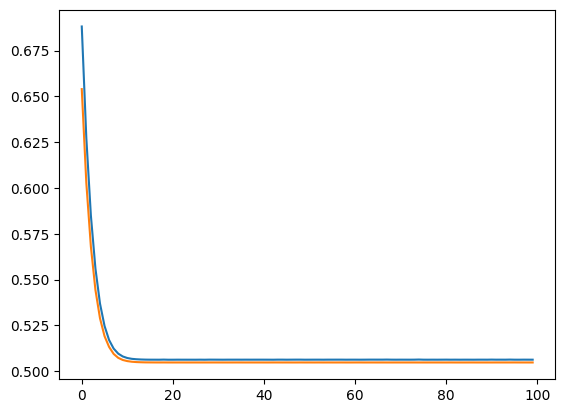

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [20]:
model.layers[0].get_weights()

[array([[ 0.02908707, -0.02395713, -0.25371125],
        [-0.38440713,  0.56668496,  0.58965135],
        [ 0.1147173 ,  0.11213088, -0.22278011],
        [ 0.1506787 , -0.3309005 , -0.4892078 ],
        [-0.09685612, -0.38948432,  0.22648656],
        [-0.4025672 ,  0.2637518 , -0.64098   ],
        [-0.4302667 , -0.49529934,  0.31856787],
        [ 0.15410453, -0.29253265, -0.4485827 ],
        [ 0.54337454, -0.59773946, -0.38337043],
        [ 0.35258245, -0.22632128, -0.22106946],
        [-0.20849863,  0.05241561,  0.63428235]], dtype=float32),
 array([ 0.000000e+00, -9.569872e-15,  0.000000e+00], dtype=float32)]

In [21]:
model.layers[1].get_weights()

[array([[-0.6280268 ],
        [ 0.08170128],
        [-1.2193146 ]], dtype=float32),
 array([-0.73329324], dtype=float32)]